# Telecomunicaciones: identificar operadores ineficaces

### Descripción

El servicio de telefonía virtual CallMeMaybe está desarrollando una nueva función que brindará a los supervisores y las supervisores información sobre los operadores menos eficaces. Se considera que **un operador es ineficaz si tiene una gran cantidad de llamadas entrantes perdidas (internas y externas) y un tiempo de espera prolongado para las llamadas entrantes**. Además, **si** se supone que un operador **debe realizar llamadas salientes, un número reducido de ellas también será un signo de ineficacia**.

- Lleva a cabo el análisis exploratorio de datos
- Identificar operadores ineficaces
- Prueba las hipótesis estadísticas

In [1]:
#Importat librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy import stats

## 1 Análisis exploratorio

### 1.1 Vistazo general

In [2]:
#Leer los datos
telecom_df = pd.read_csv("telecom_dataset_new.csv")
clients_df = pd.read_csv("telecom_clients.csv")

In [3]:
#REVISIÓN GENERAL DE LOS DATOS

In [4]:
telecom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [5]:
telecom_df

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25
...,...,...,...,...,...,...,...,...,...
53897,168606,2019-11-10 00:00:00+03:00,out,True,957922.0,True,1,0,38
53898,168606,2019-11-11 00:00:00+03:00,out,True,957922.0,False,2,479,501
53899,168606,2019-11-15 00:00:00+03:00,out,True,957922.0,False,4,3130,3190
53900,168606,2019-11-15 00:00:00+03:00,out,True,957922.0,False,4,3130,3190


In [6]:
# Contar valores ausentes por columna en telecom_df
telecom_df.isna().sum()

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [7]:
clients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


In [8]:
clients_df

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16
...,...,...,...
727,166554,B,2019-08-08
728,166911,B,2019-08-23
729,167012,B,2019-08-28
730,166867,B,2019-08-22


In [9]:
# Contar valores ausentes por columna en clients_df
clients_df.isna().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

### 1.2 Limpieza y transfomación de los datos

In [10]:
# Convertir la columna 'date' a datetime (ignorando la hora fija y zona +03:00)
telecom_df['date'] = pd.to_datetime(telecom_df['date']).dt.date

# Convertir 'operator_id' a entero nullable (Int64), manteniendo NaN como ausentes
telecom_df['operator_id'] = telecom_df['operator_id'].astype('Int64')

In [11]:
# Rellenar valores ausentes en 'internal' con "unknown"
telecom_df['internal'] = telecom_df['internal'].fillna('unknown')

# Rellenar valores ausentes en 'operator_id' con 0
telecom_df['operator_id'] = telecom_df['operator_id'].fillna(0)

In [12]:
# Mostrar los tipos de datos actuales de cada columna en telecom_df
telecom_df.dtypes

user_id                 int64
date                   object
direction              object
internal               object
operator_id             Int64
is_missed_call           bool
calls_count             int64
call_duration           int64
total_call_duration     int64
dtype: object

In [13]:
#Mostrar telecom_df actualizado
telecom_df

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04,in,False,0,True,2,0,4
1,166377,2019-08-05,out,True,880022,True,3,0,5
2,166377,2019-08-05,out,True,880020,True,1,0,1
3,166377,2019-08-05,out,True,880020,False,1,10,18
4,166377,2019-08-05,out,False,880022,True,3,0,25
...,...,...,...,...,...,...,...,...,...
53897,168606,2019-11-10,out,True,957922,True,1,0,38
53898,168606,2019-11-11,out,True,957922,False,2,479,501
53899,168606,2019-11-15,out,True,957922,False,4,3130,3190
53900,168606,2019-11-15,out,True,957922,False,4,3130,3190


In [14]:
telecom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user_id              53902 non-null  int64 
 1   date                 53902 non-null  object
 2   direction            53902 non-null  object
 3   internal             53902 non-null  object
 4   operator_id          53902 non-null  Int64 
 5   is_missed_call       53902 non-null  bool  
 6   calls_count          53902 non-null  int64 
 7   call_duration        53902 non-null  int64 
 8   total_call_duration  53902 non-null  int64 
dtypes: Int64(1), bool(1), int64(4), object(3)
memory usage: 3.4+ MB


<div style="background-color: #7FFFD4; padding: 15px; border-radius: 10px; font-weight: bold;">
El dataframe "telecom_df" ha sido limpiado y sus datos transformados a datos óptimos. Ya no hay datos ausentes.
</div>

In [15]:
# Convertir 'date_start' a tipo fecha
clients_df['date_start'] = pd.to_datetime(clients_df['date_start']).dt.date

In [16]:
# Mostrar los tipos de datos actuales de cada columna en clients_df
clients_df.dtypes

user_id         int64
tariff_plan    object
date_start     object
dtype: object

<div style="background-color: #7FFFD4; padding: 15px; border-radius: 10px; font-weight: bold;">
Para el dataframe "clients_df", sólo fue necesario asegurarse de que la columna de fecha estuviera en tipo de dato fecha.
</div>

In [17]:
# Revisar si hay filas completamente duplicadas en telecom_df
duplicados = telecom_df.duplicated()

if duplicados.sum() > 0:
   print(f"Número total de filas duplicadas: {duplicados.sum()}")
else:
    print("No hay filas duplicadas.")

Número total de filas duplicadas: 4900


In [18]:
# Eliminar filas completamente duplicadas (mantener la primera aparición)
telecom_df = telecom_df.drop_duplicates()

In [19]:
# Revisar si hay filas completamente duplicadas en clients_df
duplicados = telecom_df.duplicated()
if duplicados.sum() > 0:
   print(f"Número total de filas duplicadas: {duplicados.sum()}")
else:
    print("No hay filas duplicadas.")

No hay filas duplicadas.


### 1.3 Enriquecimiento de los datos

In [20]:
# Fusionar telecom_df con clients_df por 'user_id'
full_telecom_df = telecom_df.merge(clients_df, on='user_id', how='left')

In [21]:
full_telecom_df

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start
0,166377,2019-08-04,in,False,0,True,2,0,4,B,2019-08-01
1,166377,2019-08-05,out,True,880022,True,3,0,5,B,2019-08-01
2,166377,2019-08-05,out,True,880020,True,1,0,1,B,2019-08-01
3,166377,2019-08-05,out,True,880020,False,1,10,18,B,2019-08-01
4,166377,2019-08-05,out,False,880022,True,3,0,25,B,2019-08-01
...,...,...,...,...,...,...,...,...,...,...,...
48997,168606,2019-11-10,out,True,957922,False,1,0,25,C,2019-10-31
48998,168606,2019-11-10,out,True,957922,True,1,0,38,C,2019-10-31
48999,168606,2019-11-11,out,True,957922,False,2,479,501,C,2019-10-31
49000,168606,2019-11-15,out,True,957922,False,4,3130,3190,C,2019-10-31


In [22]:
#Descrpción estadística de los datos
full_telecom_df.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,49002.000000,49002.0,49002.000000,49002.000000,49002.000000
mean,167294.892759,777067.827068,16.462777,866.282091,1156.558202
std,598.558965,329773.738555,63.604098,3775.503352,4451.473661
min,166377.000000,0.0,1.000000,0.000000,0.000000
25%,166782.000000,890416.0,1.000000,0.000000,46.000000
50%,167158.000000,906406.0,4.000000,37.000000,208.000000
75%,167819.000000,929884.0,12.000000,570.000000,901.000000
max,168606.000000,973286.0,4817.000000,144395.000000,166155.000000


In [23]:
# Convertir las duraciones a minutos (redondeando a 2 decimales)
full_telecom_df['total_call_duration_min'] = (full_telecom_df['total_call_duration'] / 60).round(2)
full_telecom_df['call_duration_min'] = (full_telecom_df['call_duration'] / 60).round(2)

#Agregar una columna de tiempo de espera
full_telecom_df['wait_time_min'] = full_telecom_df['total_call_duration_min'] - full_telecom_df['call_duration_min']

In [24]:
full_telecom_df.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration,total_call_duration_min,call_duration_min,wait_time_min
count,49002.000000,49002.0,49002.000000,49002.000000,49002.000000,49002.000000,49002.000000,49002.000000
mean,167294.892759,777067.827068,16.462777,866.282091,1156.558202,19.275976,14.438045,4.837931
std,598.558965,329773.738555,63.604098,3775.503352,4451.473661,74.191220,62.925054,18.869256
min,166377.000000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,166782.000000,890416.0,1.000000,0.000000,46.000000,0.770000,0.000000,0.280000
50%,167158.000000,906406.0,4.000000,37.000000,208.000000,3.470000,0.620000,0.920000
75%,167819.000000,929884.0,12.000000,570.000000,901.000000,15.020000,9.500000,3.330000
max,168606.000000,973286.0,4817.000000,144395.000000,166155.000000,2769.250000,2406.580000,774.570000


In [25]:
full_telecom_df

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start,total_call_duration_min,call_duration_min,wait_time_min
0,166377,2019-08-04,in,False,0,True,2,0,4,B,2019-08-01,0.07,0.00,0.07
1,166377,2019-08-05,out,True,880022,True,3,0,5,B,2019-08-01,0.08,0.00,0.08
2,166377,2019-08-05,out,True,880020,True,1,0,1,B,2019-08-01,0.02,0.00,0.02
3,166377,2019-08-05,out,True,880020,False,1,10,18,B,2019-08-01,0.30,0.17,0.13
4,166377,2019-08-05,out,False,880022,True,3,0,25,B,2019-08-01,0.42,0.00,0.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48997,168606,2019-11-10,out,True,957922,False,1,0,25,C,2019-10-31,0.42,0.00,0.42
48998,168606,2019-11-10,out,True,957922,True,1,0,38,C,2019-10-31,0.63,0.00,0.63
48999,168606,2019-11-11,out,True,957922,False,2,479,501,C,2019-10-31,8.35,7.98,0.37
49000,168606,2019-11-15,out,True,957922,False,4,3130,3190,C,2019-10-31,53.17,52.17,1.00


In [26]:
#Calcular las llamadas entrantes y salientes totales
total_in = full_telecom_df[full_telecom_df['direction'] == 'in']['calls_count'].sum()
total_out = full_telecom_df[full_telecom_df['direction'] == 'out']['calls_count'].sum()

# Llamadas perdidas y no perdidas
in_no_perdidas = full_telecom_df[
    (full_telecom_df['direction'] == 'in') & 
    (full_telecom_df['is_missed_call'] == False)
]['calls_count'].sum()

in_perdidas = full_telecom_df[
    (full_telecom_df['direction'] == 'in') & 
    (full_telecom_df['is_missed_call'] == True)
]['calls_count'].sum()

out_no_perdidas = full_telecom_df[
    (full_telecom_df['direction'] == 'out') & 
    (full_telecom_df['is_missed_call'] == False)
]['calls_count'].sum()

out_perdidas = full_telecom_df[
    (full_telecom_df['direction'] == 'out') & 
    (full_telecom_df['is_missed_call'] == True)
]['calls_count'].sum()

# Porcentajes
in_no_pct = (in_no_perdidas / total_in) * 100
in_yes_pct = (in_perdidas / total_in) * 100
out_no_pct = (out_no_perdidas / total_out) * 100
out_yes_pct = (out_perdidas / total_out) * 100

# Imprimir cada variable con su valor
print(f"total_in: {total_in}")
print(f"total_out: {total_out}")
print(f"in_no_perdidas: {in_no_perdidas}")
print(f"in_perdidas: {in_perdidas}")
print(f"out_no_perdidas: {out_no_perdidas}")
print(f"out_perdidas: {out_perdidas}")
print(f"in_no_pct: {in_no_pct:.1f}%")
print(f"in_yes_pct: {in_yes_pct:.1f}%")
print(f"out_no_pct: {out_no_pct:.1f}%")
print(f"out_yes_pct: {out_yes_pct:.1f}%")

total_in: 197845
total_out: 608864
in_no_perdidas: 93522
in_perdidas: 104323
out_no_perdidas: 337269
out_perdidas: 271595
in_no_pct: 47.3%
in_yes_pct: 52.7%
out_no_pct: 55.4%
out_yes_pct: 44.6%


### 1.4 Exploración visual de los datos

In [27]:
#VISUALIZACIONES

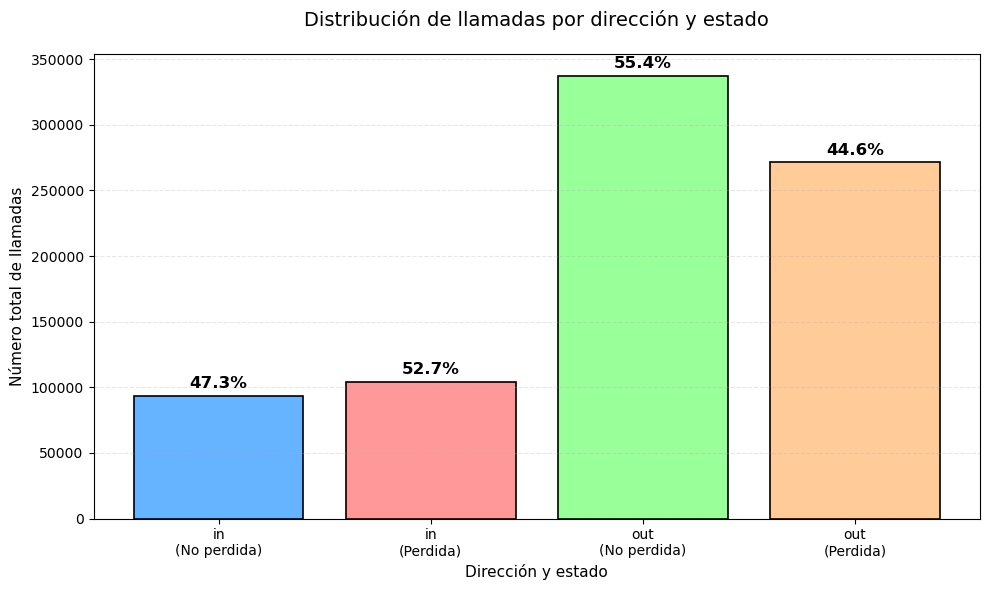

In [28]:
# 1. Distribución de llamadas por dirección
categories = ['in\n(No perdida)', 'in\n(Perdida)', 'out\n(No perdida)', 'out\n(Perdida)']
values = [in_no_perdidas, in_perdidas, out_no_perdidas, out_perdidas]
percentages = [f'{in_no_pct:.1f}%', f'{in_yes_pct:.1f}%', f'{out_no_pct:.1f}%', f'{out_yes_pct:.1f}%']
colors = ['#66b3ff', '#ff9999', '#99ff99', '#ffcc99']  # Colores claros

plt.figure(figsize=(10, 6))
bars = plt.bar(categories, values, color=colors, edgecolor='black', linewidth=1.2)

# Añadir porcentajes encima de cada barra
for i, (bar, pct) in enumerate(zip(bars, percentages)):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (0.01 * max(values)),
        pct,
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# Títulos y formato
plt.title('Distribución de llamadas por dirección y estado', 
          fontsize=14, pad=20)
plt.ylabel('Número total de llamadas', fontsize=11)
plt.xlabel('Dirección y estado', fontsize=11)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13064\3422070584.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


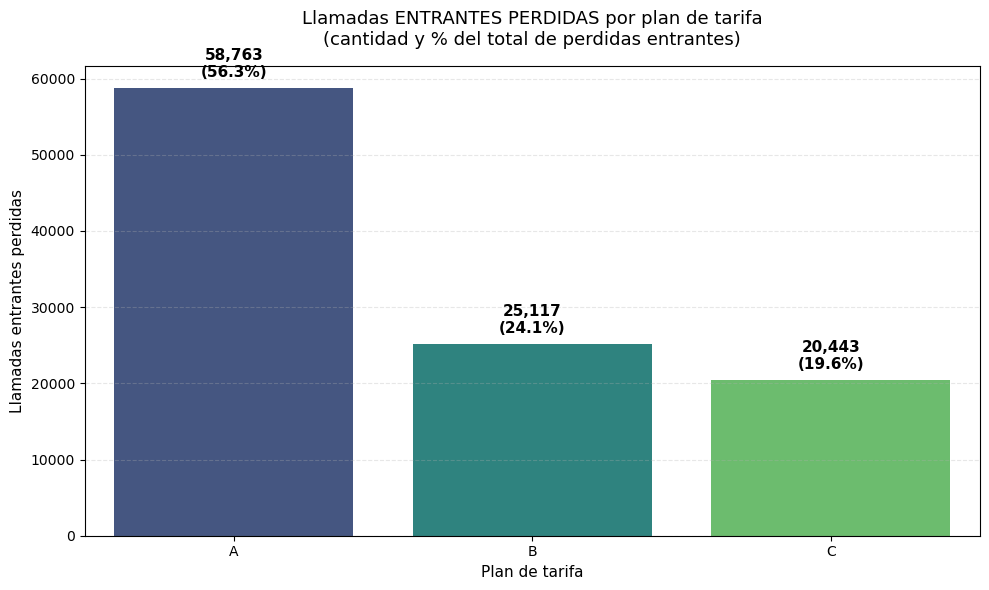

In [29]:
# 2. Llamadas ENTRANTES PERDIDAS por plan de tarifa
plt.figure(figsize=(10, 6))

# Filtrar: solo llamadas ENTRANTES y PERDIDAS
missed_in_by_plan = (
    full_telecom_df[
        (full_telecom_df['direction'] == 'in') & 
        (full_telecom_df['is_missed_call'] == True)
    ]
    .groupby('tariff_plan')['calls_count']
    .sum()
    .reset_index()
    .sort_values('calls_count', ascending=False)
)

# 1. Total general de llamadas entrantes perdidas (100%)
total_missed_in = missed_in_by_plan['calls_count'].sum()

# 2. Porcentaje por plan
missed_in_by_plan['percentage'] = (missed_in_by_plan['calls_count'] / total_missed_in) * 100

# === GRÁFICO ===
ax = sns.barplot(
    data=missed_in_by_plan,
    x='tariff_plan',
    y='calls_count',
    palette='viridis',
    order=missed_in_by_plan['tariff_plan']
)

# 3. Etiquetas: cantidad + porcentaje
for i, row in enumerate(missed_in_by_plan.itertuples()):
    ax.text(
        i,
        row.calls_count + (0.01 * total_missed_in),
        f'{row.calls_count:,}\n({row.percentage:.1f}%)',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=11
    )

plt.title('Llamadas ENTRANTES PERDIDAS por plan de tarifa\n'
          '(cantidad y % del total de perdidas entrantes)', fontsize=13, pad=15)
plt.xlabel('Plan de tarifa', fontsize=11)
plt.ylabel('Llamadas entrantes perdidas', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13064\2101483859.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=in_data_all, x='is_missed_call', y='wait_time_min', palette='Blues')


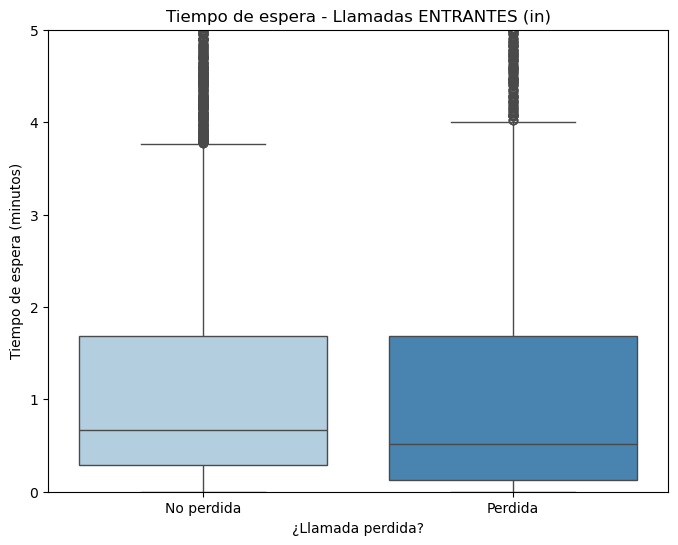

In [30]:
# 3. Tiempo de espera promedio por llamada (total_call_duration - call_duration)

in_data_all = full_telecom_df[full_telecom_df['direction'] == 'in']

plt.figure(figsize=(8, 6))
sns.boxplot(data=in_data_all, x='is_missed_call', y='wait_time_min', palette='Blues')
plt.ylim(0, 5)
plt.title('Tiempo de espera - Llamadas ENTRANTES (in)')
plt.xlabel('¿Llamada perdida?')
plt.ylabel('Tiempo de espera (minutos)')
plt.xticks([0, 1], ['No perdida', 'Perdida'])
plt.show()

In [31]:
#Tiempo promedio de espera para llamadas entrantes
in_wait_mean = in_data_all.groupby('is_missed_call')['wait_time_min'].mean()
print("Tiempo PROMEDIO en minutos de espera para llamadas entrantes:")
print(in_wait_mean)

#Mediana del tiempo de espera para llamadas entrantes
in_wait_median = in_data_all.groupby('is_missed_call')['wait_time_min'].median()
print("MEDIANA del tiempo de espera en minutos para llamadas entrantes:")
print(in_wait_median)

#Desviación estándar del tiempo de espera para llamadas entrantes
in_wait_std = in_data_all.groupby('is_missed_call')['wait_time_min'].std()
print("DESVIACIÓN ESTÁNDAR del tiempo de espera en minutos para llamadas entrantes:")
print(in_wait_std)

#Valores del cuarto cuartil (bigote superior) para llamadas entrantes (Q3 + 1.5*IQR)
in_wait_Q1 = in_data_all.groupby('is_missed_call')['wait_time_min'].quantile(0.25)
in_wait_Q3 = in_data_all.groupby('is_missed_call')['wait_time_min'].quantile(0.75)
in_wait_IQR = in_wait_Q3 - in_wait_Q1
in_wait_upper_whisker = in_wait_Q3 + 1.5 * in_wait_IQR
print("Valores del CUARTO CUARTIL (bigote superior) para llamadas entrantes:")
print(in_wait_upper_whisker)


Tiempo PROMEDIO en minutos de espera para llamadas entrantes:
is_missed_call
False    1.676827
True     2.700426
Name: wait_time_min, dtype: float64
MEDIANA del tiempo de espera en minutos para llamadas entrantes:
is_missed_call
False    0.67
True     0.52
Name: wait_time_min, dtype: float64
DESVIACIÓN ESTÁNDAR del tiempo de espera en minutos para llamadas entrantes:
is_missed_call
False     3.149976
True     13.657999
Name: wait_time_min, dtype: float64
Valores del CUARTO CUARTIL (bigote superior) para llamadas entrantes:
is_missed_call
False    3.765
True     4.005
Name: wait_time_min, dtype: float64


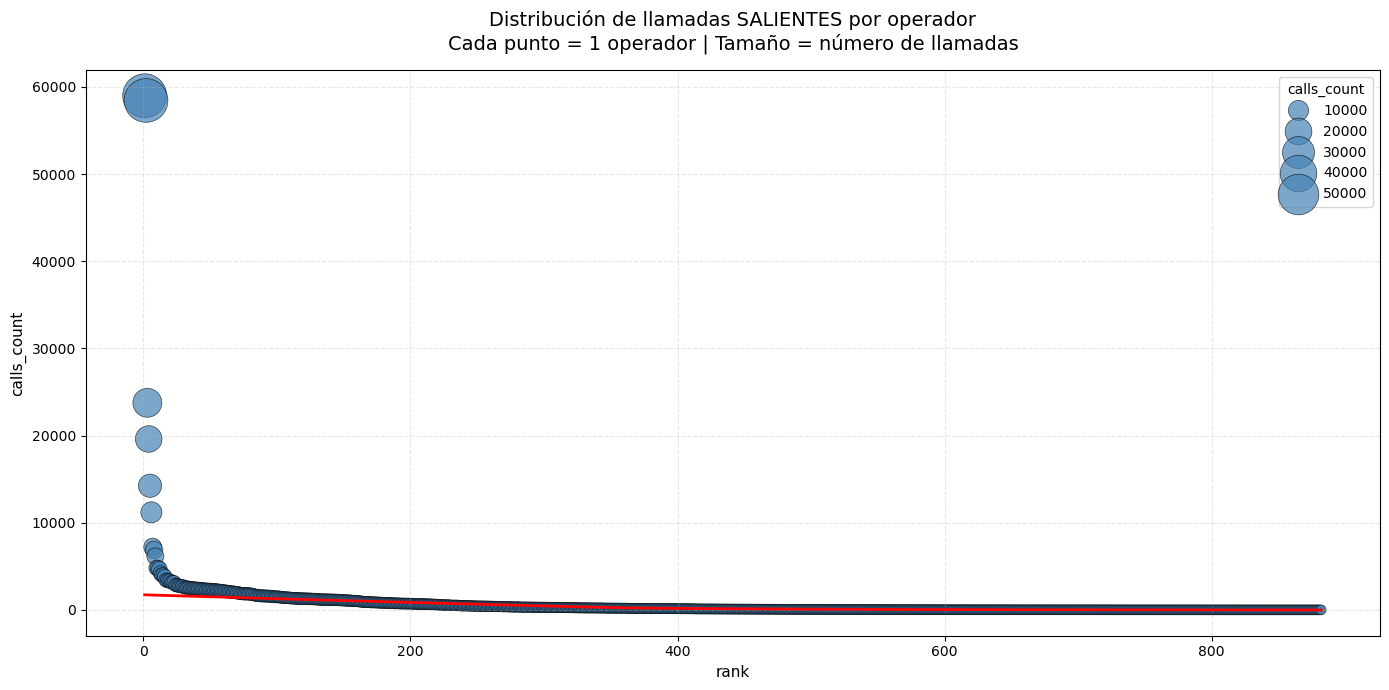

Operadores con llamadas salientes: 882
Media: 690
Mediana: 90
Desviación estandar: 3123
Top 1: 58,977 llamadas
Bottom 1: 1 llamadas


In [32]:
# 5. Gráfico de dispersión de llamadas salientes
outgoing = full_telecom_df[
    (full_telecom_df['direction'] == 'out') &
    (full_telecom_df['operator_id']!=0)
]

# Agrupar por operador: total de llamadas salientes
outgoing_by_operator = (
    outgoing.groupby('operator_id')['calls_count']
    .sum()
    .reset_index()
    .sort_values('calls_count', ascending=False)
)

# Añadir ranking para eje X (opcional, para mejor visualización)
outgoing_by_operator['rank'] = range(1, len(outgoing_by_operator) + 1)

# === GRÁFICO: Scatter plot ===
plt.figure(figsize=(14, 7))

# Scatter con tamaño proporcional al número de llamadas
sns.scatterplot(
    data=outgoing_by_operator,
    x='rank',
    y='calls_count',
    size='calls_count',
    sizes=(50, 1000),
    alpha=0.7,
    color='steelblue',
    edgecolor='black',
    linewidth=0.5
)

plt.title('Distribución de llamadas SALIENTES por operador\n'
          'Cada punto = 1 operador | Tamaño = número de llamadas', 
          fontsize=14, pad=15)
plt.xlabel('Ranking de operadores (1 = más activo)', fontsize=11)
plt.ylabel('Número de llamadas salientes', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)

# Línea de tendencia (opcional, para ver distribución)
sns.regplot(
    data=outgoing_by_operator,
    x='rank',
    y='calls_count',
    scatter=False,
    color='red',
    lowess=True,
    line_kws={'linewidth': 2}
)

plt.tight_layout()
plt.show()

# === Estadísticas rápidas (opcional) ===
print(f"Operadores con llamadas salientes: {len(outgoing_by_operator)}")
print(f"Media: {outgoing_by_operator['calls_count'].mean():.0f}")
print(f"Mediana: {outgoing_by_operator['calls_count'].median():.0f}")
print(f"Desviación estandar: {outgoing_by_operator['calls_count'].std():.0f}")
print(f"Top 1: {outgoing_by_operator.iloc[0]['calls_count']:,} llamadas")
print(f"Bottom 1: {outgoing_by_operator.iloc[-1]['calls_count']:,} llamadas")

In [33]:
# Promedio de llamadas salientes por operador
avg_calls = outgoing_by_operator['calls_count'].mean()

# Contar cuántos están por debajo del promedio
below_avg = outgoing_by_operator[outgoing_by_operator['calls_count'] < avg_calls]
num_below_avg = len(below_avg)
print(f"Operadores por debajo del promedio: {num_below_avg} ({num_below_avg/len(outgoing_by_operator)*100:.1f}%)")

Operadores por debajo del promedio: 679 (77.0%)


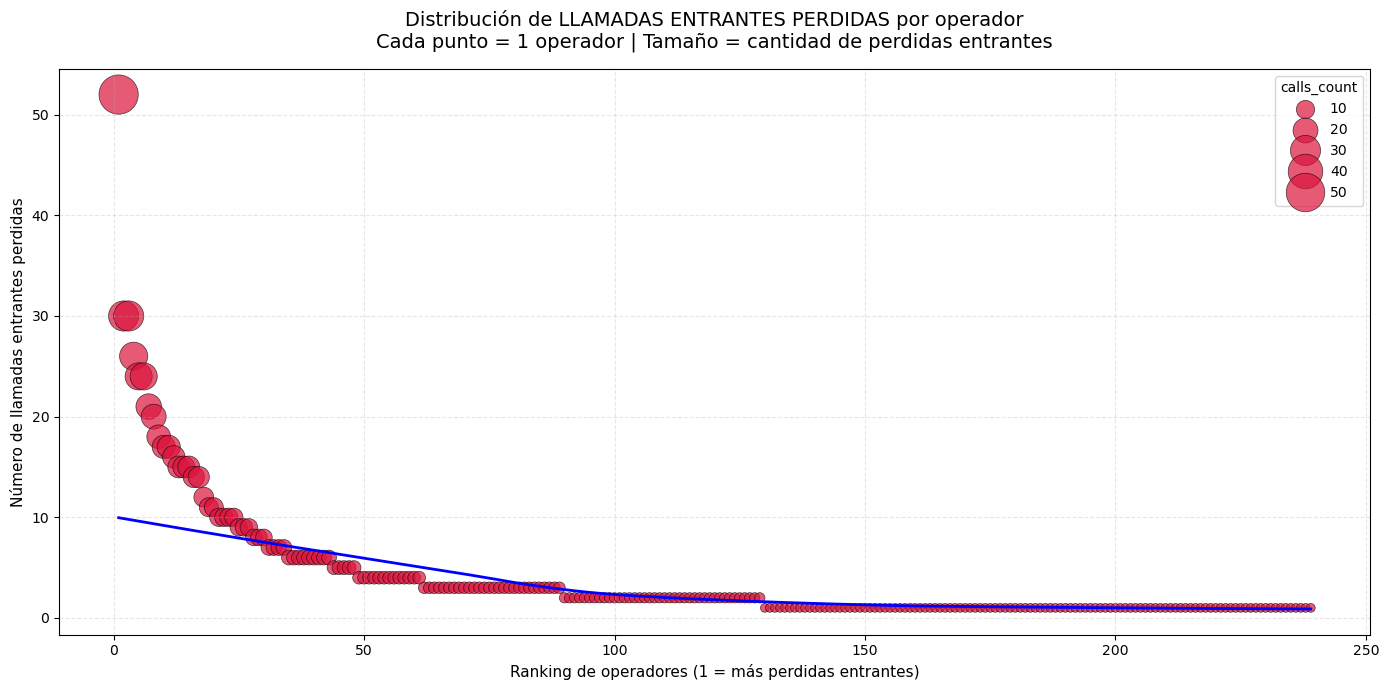

In [34]:
# 5. Gráfico de dispersión de LLAMADAS ENTRANTES PERDIDAS por operador
plt.figure(figsize=(14, 7))

# === FILTRADO CORRECTO ===
# Solo: entrantes + perdidas + operador asignado (no nulos)
missed_in_calls = full_telecom_df[
    (full_telecom_df['direction'] == 'in') &
    (full_telecom_df['is_missed_call'] == True) &
    (full_telecom_df['operator_id']!=0)
]

# === AGRUPACIÓN POR OPERADOR ===
missed_in_by_operator = (
    missed_in_calls.groupby('operator_id')['calls_count']
    .sum()
    .reset_index()
    .sort_values('calls_count', ascending=False)
)

# Añadir ranking
missed_in_by_operator['rank'] = range(1, len(missed_in_by_operator) + 1)

# === GRÁFICO ===
sns.scatterplot(
    data=missed_in_by_operator,
    x='rank',
    y='calls_count',
    size='calls_count',
    sizes=(40, 800),
    alpha=0.7,
    color='crimson',
    edgecolor='black',
    linewidth=0.5
)

# Línea de tendencia (LOWESS)
sns.regplot(
    data=missed_in_by_operator,
    x='rank',
    y='calls_count',
    scatter=False,
    color='blue',
    lowess=True,
    line_kws={'linewidth': 2}
)

plt.title('Distribución de LLAMADAS ENTRANTES PERDIDAS por operador\n'
          'Cada punto = 1 operador | Tamaño = cantidad de perdidas entrantes',
          fontsize=14, pad=15)
plt.xlabel('Ranking de operadores (1 = más perdidas entrantes)', fontsize=11)
plt.ylabel('Número de llamadas entrantes perdidas', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# === ESTADÍSTICAS RÁPIDAS (actualizadas) ===
print(f"Operadores con al menos 1 llamada entrante perdida: {len(missed_in_by_operator)}")
print(f"Total de llamadas entrantes perdidas (asignadas): {missed_in_by_operator['calls_count'].sum():,}")

avg_missed_in = missed_in_by_operator['calls_count'].mean()
median_missed_in = missed_in_by_operator['calls_count'].median()
std_missed_in = missed_in_by_operator['calls_count'].std()

print(f"Promedio por operador: {avg_missed_in:.1f}")
print(f"Mediana: {median_missed_in:.1f}")
print(f"Desviación estándar: {std_missed_in:.0f}")
print(f"Máximo (peor operador): {missed_in_by_operator.iloc[0]['calls_count']:,} perdidas entrantes")

# Operadores por encima del promedio
above_avg = missed_in_by_operator[missed_in_by_operator['calls_count'] > avg_missed_in]
num_above_avg = len(above_avg)
print(f"Operadores por encima del promedio: {num_above_avg} "
      f"({num_above_avg/len(missed_in_by_operator)*100:.1f}%)")

Operadores con al menos 1 llamada entrante perdida: 239
Total de llamadas entrantes perdidas (asignadas): 926
Promedio por operador: 3.9
Mediana: 2.0
Desviación estándar: 6
Máximo (peor operador): 52 perdidas entrantes
Operadores por encima del promedio: 61 (25.5%)


### Observaciones:

<div style="background-color: #7FFFD4; padding: 15px; border-radius: 10px; font-weight: bold;">

- Hasta el 52.7% de las llamadas entrantes, son llamdas perdidas.
- El plan A de tarifas, es el que presenta la mayor cantidad de llamadas perdidas; con el 57%.
- En cuanto al tiempo de espera de las llamadas entrantes, el promedio para las perdidas es de 2.7 minutos y para las no perdidas de 1.67 minutos; el tiempo máximo para las perdidas es de 4 minutos y para las no perdidas de 3.7 minutos.
- En cuanto a los operadores con al menos una llamada perdida, se encontraron 61 (25.5%) operadores tiene llamadas perdidas por encima del promedio (3.9 llamadas).
- Sobre el número de llamadas salientes por operador, hasta 680 (77%) operadores hacen menos llamadas (salientes) que el promedio por operador (690).
</div>

### Conjeturas:

<div style="background-color:#7FFFD4; padding: 15px; border-radius: 10px; font-weight: bold;">

Se considerará como operadores ineficaces, a todos aquellos que tengan las siguientes caracteríasticas:

- Tengan más llamadas perdidas que el promedio + una desviación estándar, es decir, más de 10 llamadas perdidas.
- Hayan hecho menos llamadas (salientes) que el promedio - la mediana, es decir, menos de 600 llamadas salientes.
- Tengan un tiempo de espera mayor a 4 minutos.

Probablemente, la moyoría de los operadores ineficaces, atienden al plan tarifario A.
</div>

## 2 Identificación de los operadores más ineficaces

### 2.1 Definir las variables clave por operador (features) y creación del conjunto de datos (dataset)

Variable,Descripción

total_incoming,Total de llamadas entrantes

missed_incoming,Llamadas entrantes perdidas

miss_rate_in,% de entrantes perdidas

avg_wait_time_in,Tiempo promedio de espera (entrantes)

total_outgoing,Total de llamadas salientes

missed_outgoing,Llamadas salientes perdidas

miss_rate_out,% de salientes perdidas

total_calls,Actividad total

In [36]:
# === CREAR DATAFRAME DE OPERADORES CON MÉTRICAS CLAVE ===

In [37]:
# 1. Llamadas entrantes (in)
incoming = full_telecom_df[full_telecom_df['direction'] == 'in'].copy()
incoming['wait_time_min'] = (incoming['total_call_duration'] - incoming['call_duration']) / 60

# USAR EL MISMO DATAFRAME 'incoming' DENTRO DEL GRUPO
in_metrics = incoming.groupby('operator_id').apply(
    lambda g: pd.Series({
        'total_incoming': g['calls_count'].sum(),
        'missed_incoming': g[g['is_missed_call'] == True]['calls_count'].sum(),
        'total_wait_time': g['wait_time_min'].sum(),
        'incoming_calls_count': len(g)
    })
).reset_index()

# Promedio de espera
in_metrics['avg_wait_time_in'] = in_metrics['total_wait_time'] / in_metrics['incoming_calls_count'].replace(0, 1)

# === VERIFICAR QUE NO ESTÉ EN CERO ===
print(f"Operadores con llamadas entrantes: {len(in_metrics)}")
print(f"Operadores con missed_incoming > 0: {len(in_metrics[in_metrics['missed_incoming'] > 0])}")
display(in_metrics[in_metrics['missed_incoming'] > 0].sort_values('missed_incoming', ascending=False).reset_index(drop=True))

Operadores con llamadas entrantes: 755
Operadores con missed_incoming > 0: 240


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13064\3145045096.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  in_metrics = incoming.groupby('operator_id').apply(


,operator_id,total_incoming,missed_incoming,total_wait_time,incoming_calls_count,avg_wait_time_in
0,0,104043.0,103397.0,21060.533333,7270.0,2.896910
1,913942,2467.0,52.0,492.883333,85.0,5.798627
2,940588,2127.0,30.0,110.266667,52.0,2.120513
3,944226,180.0,30.0,127.983333,50.0,2.559667
4,885890,1244.0,26.0,188.433333,94.0,2.004610
...,...,...,...,...,...,...
235,955032,38.0,1.0,5.466667,12.0,0.455556
236,958640,10.0,1.0,1.750000,10.0,0.175000
237,958452,27.0,1.0,5.783333,12.0,0.481944
238,960620,50.0,1.0,12.466667,10.0,1.246667


In [38]:
# 2. Llamadas salientes (out)
outgoing = full_telecom_df[full_telecom_df['direction'] == 'out']

out_metrics = outgoing.groupby('operator_id').agg(
    total_outgoing=('calls_count', 'sum'),
    missed_outgoing=('is_missed_call', lambda x: outgoing[outgoing['is_missed_call']]['calls_count'].sum() 
                     if 'calls_count' in outgoing else 0)
).reset_index()

# 3. Determinar el plan tarifario dominante por operador
# (el que más llamadas atendió)
plan_dominant = full_telecom_df.groupby(['operator_id', 'tariff_plan'])['calls_count'].sum().reset_index()
plan_dominant = plan_dominant.sort_values(['operator_id', 'calls_count'], ascending=[True, False])
plan_dominant = plan_dominant.groupby('operator_id').first().reset_index()[['operator_id', 'tariff_plan']]

In [39]:
# 4. Unir todo
operators_df = in_metrics.merge(out_metrics, on='operator_id', how='outer')
operators_df = operators_df.merge(plan_dominant, on='operator_id', how='left')

# Rellenar NaN
operators_df.fillna({
    'total_incoming': 0, 'missed_incoming': 0, 'total_wait_time': 0, 'incoming_calls_count': 0,
    'avg_wait_time_in': 0, 'total_outgoing': 0, 'missed_outgoing': 0,
    'tariff_plan': 'unknown'
}, inplace=True)

# 5. Métricas derivadas
operators_df['miss_rate_in'] = operators_df['missed_incoming'] / operators_df['total_incoming'].replace(0, 1)
operators_df['miss_rate_out'] = operators_df['missed_outgoing'] / operators_df['total_outgoing'].replace(0, 1)

# 6. Filtrar operadores con al menos 1 llamada (entrante o saliente)
#    y excluir operator_id = 0 (desconocido → ruido para clustering)
operators_df = operators_df[
    (operators_df['total_incoming'] > 0) |
    (operators_df['total_outgoing'] > 0)
]

# Excluir operador desconocido
operators_df = operators_df[operators_df['operator_id'] != 0].reset_index(drop=True)


In [40]:
# === RESULTADO FINAL: operators_df ===
print(f"DataFrame creado: {operators_df.shape[0]} operadores con al menos 1 llamada")
print(f"Columnas: {list(operators_df.columns)}")
display(operators_df[operators_df["missed_incoming"]>0])

DataFrame creado: 1092 operadores con al menos 1 llamada
Columnas: ['operator_id', 'total_incoming', 'missed_incoming', 'total_wait_time', 'incoming_calls_count', 'avg_wait_time_in', 'total_outgoing', 'missed_outgoing', 'tariff_plan', 'miss_rate_in', 'miss_rate_out']


,operator_id,total_incoming,missed_incoming,total_wait_time,incoming_calls_count,avg_wait_time_in,total_outgoing,missed_outgoing,tariff_plan,miss_rate_in,miss_rate_out
10,882680,99.0,3.0,26.516667,43.0,0.616667,0.0,0.0,B,0.030303,0.000000
11,882684,613.0,4.0,158.766667,50.0,3.175333,661.0,271595.0,B,0.006525,410.885023
12,882686,766.0,6.0,187.850000,68.0,2.762500,2884.0,271595.0,B,0.007833,94.173024
14,882690,171.0,2.0,118.366667,22.0,5.380303,1417.0,271595.0,B,0.011696,191.669019
22,884408,35.0,4.0,15.400000,14.0,1.100000,25.0,271595.0,B,0.114286,10863.800000
...,...,...,...,...,...,...,...,...,...,...,...
1021,959312,56.0,7.0,6.966667,13.0,0.535897,145.0,271595.0,C,0.125000,1873.068966
1025,960620,50.0,1.0,12.466667,10.0,1.246667,58.0,271595.0,A,0.020000,4682.672414
1043,964510,15.0,2.0,2.500000,6.0,0.416667,131.0,271595.0,C,0.133333,2073.244275
1045,964666,43.0,3.0,9.633333,9.0,1.070370,814.0,271595.0,A,0.069767,333.654791


### 2.2 Adecuación de los datos para el agrupamiento de los datos

In [41]:
# 1. Eliminar outliers extremos con IQR (por variable clave)
def remove_outliers_iqr(df, column, factor=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

# Variables críticas para eliminar outliers
outlier_cols = ['missed_incoming', 'total_outgoing', 'avg_wait_time_in', 'miss_rate_in']

operators_clean = operators_df.copy()
for col in outlier_cols:
    operators_clean = remove_outliers_iqr(operators_clean, col)

print(f"Operadores tras eliminar outliers: {operators_clean.shape[0]} "
      f"(de {operators_df.shape[0]} originales)")

Operadores tras eliminar outliers: 680 (de 1092 originales)


In [42]:
# 2. Excluir operator_id = 0 (ruido para clustering)
operators_clean = operators_clean[operators_clean['operator_id'] != 0].reset_index(drop=True)

# 3. Codificar variable categórica 'tariff_plan' (One-Hot Encoding)
operators_encoded = pd.get_dummies(operators_clean, columns=['tariff_plan'], prefix='plan')

# 4. Seleccionar variables para clustering
features = [
    'total_incoming', 'missed_incoming', 'miss_rate_in',
    'avg_wait_time_in', 'total_outgoing', 'miss_rate_out',
    'plan_A', 'plan_B', 'plan_C'
]

X = operators_encoded[features]

In [43]:
# 5. Escalar variables (StandardScaler → media 0, desv. 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir a DataFrame para mejor manejo
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=operators_encoded.index)

print(f"\nVariables escaladas: {features}")
print("Listo para clustering (K-Means, DBSCAN, etc.)")


Variables escaladas: ['total_incoming', 'missed_incoming', 'miss_rate_in', 'avg_wait_time_in', 'total_outgoing', 'miss_rate_out', 'plan_A', 'plan_B', 'plan_C']
Listo para clustering (K-Means, DBSCAN, etc.)


### 2.3 Determinar número óptimo de clústeres (método del codo + Silhouette Score).

In [44]:
# Rango de clústeres a probar
range_n_clusters = range(2, 11)

# Almacenar métricas
inertias = []
silhouette_scores = []

for n_clusters in range_n_clusters:
    # Aplicar K-Means
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled_df)
    
    # Inercia (para método del codo)
    inertias.append(kmeans.inertia_)
    
    # Silhouette Score
    silhouette_avg = silhouette_score(X_scaled_df, cluster_labels)
    silhouette_scores.append(silhouette_avg)

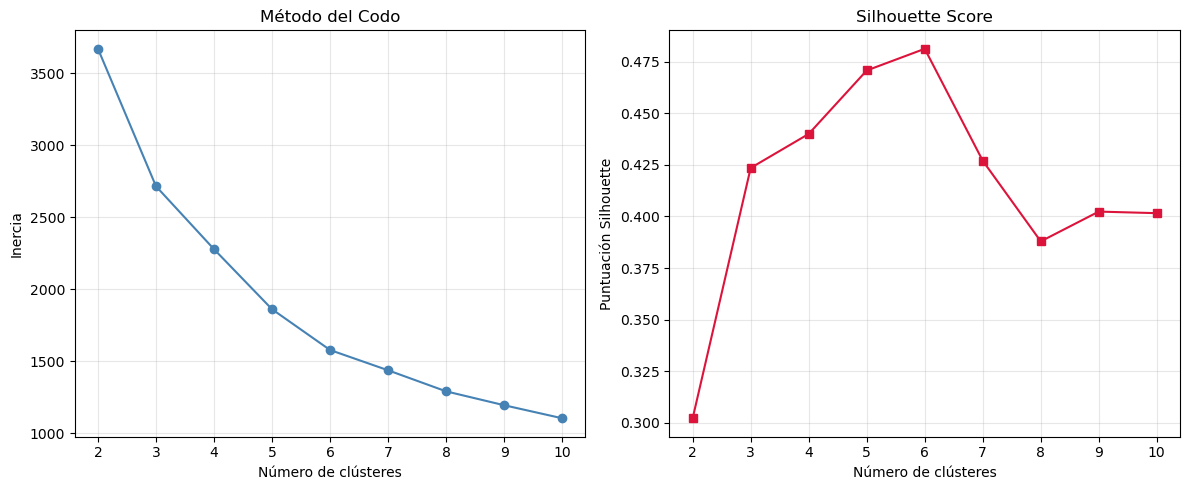

In [45]:
# === GRÁFICO 1: MÉTODO DEL CODO ===
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, inertias, marker='o', color='steelblue')
plt.title('Método del Codo')
plt.xlabel('Número de clústeres')
plt.ylabel('Inercia')
plt.grid(True, alpha=0.3)

# === GRÁFICO 2: SILHOUETTE SCORE ===
plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouette_scores, marker='s', color='crimson')
plt.title('Silhouette Score')
plt.xlabel('Número de clústeres')
plt.ylabel('Puntuación Silhouette')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
# === RECOMENDACIÓN AUTOMÁTICA + DIAGNÓSTICO DE CALIDAD ===
best_n_codo = range_n_clusters[inertias.index(min(inertias))]
best_n_sil = range_n_clusters[silhouette_scores.index(max(silhouette_scores))]

print(f"\nRecomendación:")
print(f" - Método Cern: buscar 'codo' visual (si hay cambio brusco)")
print(f" - Silhouette Score máximo: {best_n_sil} clústeres (puntuación: {max(silhouette_scores):.3f})")

# === DIAGNÓSTICO DE CALIDAD DEL CLUSTERING ===
if max(silhouette_scores) > 0.5:
    print("Datos adecuados para proceder con el clustering.")
elif max(silhouette_scores) > 0.3:
    print("Clustering posible, pero con calidad moderada (no recomendado).")
else:
    print("No hay clústeres naturales claros, no se recomienda seguir con el clustering.")


Recomendación:
 - Método Cern: buscar 'codo' visual (si hay cambio brusco)
 - Silhouette Score máximo: 6 clústeres (puntuación: 0.481)
Clustering posible, pero con calidad moderada (no recomendado).


In [47]:
operators_clean

,operator_id,total_incoming,missed_incoming,total_wait_time,incoming_calls_count,avg_wait_time_in,total_outgoing,missed_outgoing,tariff_plan,miss_rate_in,miss_rate_out
0,880020,7.0,0.0,0.900000,7.0,0.128571,38.0,271595.0,B,0.0,7147.236842
1,880022,8.0,0.0,1.866667,8.0,0.233333,189.0,271595.0,B,0.0,1437.010582
2,880240,0.0,0.0,0.000000,0.0,0.000000,47.0,271595.0,B,0.0,5778.617021
3,881278,0.0,0.0,0.000000,0.0,0.000000,20.0,271595.0,B,0.0,13579.750000
4,882476,3.0,0.0,1.583333,3.0,0.527778,0.0,0.0,C,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
675,972408,0.0,0.0,0.000000,0.0,0.000000,6.0,271595.0,B,0.0,45265.833333
676,972410,0.0,0.0,0.000000,0.0,0.000000,77.0,271595.0,B,0.0,3527.207792
677,972412,1.0,0.0,0.416667,1.0,0.416667,60.0,271595.0,B,0.0,4526.583333
678,972460,1.0,0.0,0.066667,1.0,0.066667,50.0,271595.0,C,0.0,5431.900000


<div style="background-color:#7FFFD4; padding: 15px; border-radius: 10px; font-weight: bold;">

Dado que la evaluación de los datos para agruparlos en conjuntos que compartan características similares (clústers) resutó NO RECOMENDADA (silhouette < 0.5 y SIN un codo claro con el método del codo), NO se continuará con el agrupamiento de los datos y se optará por una clasificación manual, tomando en cuenta los criterios mensionados anteriormente.
</div>

### 2.4 Clasificación manual

<div style="background-color:#7FFFD4; padding: 15px; border-radius: 10px; font-weight: bold;">
Criterios para identificar a opradores ineficaces:

- Más de 10 llamadas perdidas.
- Menos de 600 llamadas salientes.
- Tiempo de espera mayor a 4 minutos, para llamdas entrantes.
</div>

In [48]:
# === IDENTIFICAR OPERADORES INEFICACES SEGÚN CRITERIOS ===
ineficaces = operators_df[
    (operators_df['missed_incoming'] > 10) &
    (operators_df['total_outgoing'] < 600) &
    (operators_df['avg_wait_time_in'] > 4)
].copy()

# Ordenar por gravedad (más perdidas primero)
ineficaces = ineficaces.sort_values('missed_incoming', ascending=False)

# Mostrar resultados
print(f"OPERADORES INEFICACES IDENTIFICADOS: {len(ineficaces)}")
print("="*80)

if len(ineficaces) > 0:
    # Mostrar tabla con métricas clave
    resultado = ineficaces[[
        'operator_id', 'tariff_plan',
        'missed_incoming', 'total_outgoing', 'avg_wait_time_in',
        'miss_rate_in'
    ]].copy()
    
    # Formatear
    resultado['miss_rate_in'] = (resultado['miss_rate_in'] * 100).round(1).astype(str) + '%'
    resultado['avg_wait_time_in'] = resultado['avg_wait_time_in'].round(2)
    
    display(resultado)
    
    # Estadísticas
    print(f"\nResumen:")
    print(f" - Plan A: {sum(ineficaces['tariff_plan'] == 'A')} operadores")
    print(f" - Plan B: {sum(ineficaces['tariff_plan'] == 'B')} operadores")
    print(f" - Plan C: {sum(ineficaces['tariff_plan'] == 'C')} operadores")
    print(f" - Promedio de perdidas: {ineficaces['missed_incoming'].mean():.0f}")
    print(f" - Máximo de perdidas: {ineficaces['missed_incoming'].max():,}")
else:
    print("No se encontraron operadores que cumplan TODOS los criterios de ineficacia.")

OPERADORES INEFICACES IDENTIFICADOS: 3


,operator_id,tariff_plan,missed_incoming,total_outgoing,avg_wait_time_in,miss_rate_in
369,913942,B,52.0,440.0,5.80,2.1%
368,913938,B,14.0,408.0,8.78,0.3%
465,919554,B,11.0,11.0,8.39,0.9%



Resumen:
 - Plan A: 0 operadores
 - Plan B: 3 operadores
 - Plan C: 0 operadores
 - Promedio de perdidas: 26
 - Máximo de perdidas: 52.0


In [49]:
# === CLASIFICACIÓN MANUAL: OPERADORES QUE CUMPLEN AL MENOS 2 CRITERIOS ===

# Definir condiciones
cond1 = operators_df['missed_incoming'] > 10
cond2 = operators_df['total_outgoing'] < 600
cond3 = operators_df['avg_wait_time_in'] > 4

# Contar cuántas condiciones cumple cada operador
operators_df['criterios_cumplidos'] = cond1.astype(int) + cond2.astype(int) + cond3.astype(int)

# Filtrar: al menos 2 criterios
ineficaces_2 = operators_df[operators_df['criterios_cumplidos'] >= 2].copy()

# Ordenar por número de criterios y luego por perdidas
ineficaces_2 = ineficaces_2.sort_values(
    ['criterios_cumplidos', 'missed_incoming'], 
    ascending=[False, False]
)

# Mostrar resultados
print(f"OPERADORES CON AL MENOS 2 CRITERIOS DE INEFICACIA: {len(ineficaces_2)}")
print("="*90)

if len(ineficaces_2) > 0:
    # Tabla final
    resultado = ineficaces_2[[
        'operator_id', 'tariff_plan',
        'missed_incoming', 'total_outgoing', 'avg_wait_time_in',
        'miss_rate_in', 'criterios_cumplidos'
    ]].copy()
    
    # Formatear
    resultado['miss_rate_in'] = (resultado['miss_rate_in'] * 100).round(1).astype(str) + '%'
    resultado['avg_wait_time_in'] = resultado['avg_wait_time_in'].round(2)
    resultado['criterios_cumplidos'] = resultado['criterios_cumplidos'].astype(str) + '/3'
    
    display(resultado)
    
    # Resumen
    print(f"\nResumen:")
    print(f" - Cumplen 3/3: {sum(ineficaces_2['criterios_cumplidos'] == 3)}")
    print(f" - Cumplen 2/3: {sum(ineficaces_2['criterios_cumplidos'] == 2)}")
    print(f" - Plan A: {sum(ineficaces_2['tariff_plan'] == 'A')}")
    print(f" - Plan B: {sum(ineficaces_2['tariff_plan'] == 'B')}")
    print(f" - Plan C: {sum(ineficaces_2['tariff_plan'] == 'C')}")
    print(f" - Promedio de llamadas perdidas: {ineficaces_2['missed_incoming'].mean():.0f}")
else:
    print("No se encontraron operadores que cumplan al menos 2 criterios.")

OPERADORES CON AL MENOS 2 CRITERIOS DE INEFICACIA: 32


,operator_id,tariff_plan,missed_incoming,total_outgoing,avg_wait_time_in,miss_rate_in,criterios_cumplidos
369,913942,B,52.0,440.0,5.80,2.1%,3/3
368,913938,B,14.0,408.0,8.78,0.3%,3/3
465,919554,B,11.0,11.0,8.39,0.9%,3/3
779,940588,A,30.0,67.0,2.12,1.4%,2/3
823,944226,B,30.0,109.0,2.56,16.7%,2/3
722,937956,A,24.0,1.0,0.29,3.1%,2/3
819,944216,B,24.0,133.0,2.68,10.2%,2/3
936,951508,A,21.0,146.0,3.22,6.2%,2/3
821,944220,B,18.0,221.0,3.12,6.8%,2/3
786,940630,A,17.0,127.0,2.77,0.9%,2/3



Resumen:
 - Cumplen 3/3: 3
 - Cumplen 2/3: 29
 - Plan A: 12
 - Plan B: 14
 - Plan C: 6
 - Promedio de llamadas perdidas: 12


In [50]:
# === CLASIFICACIÓN MANUAL: OPERADORES QUE CUMPLEN AL MENOS 1 CRITERIO ===

# Definir condiciones
cond1 = operators_df['missed_incoming'] > 10
cond2 = operators_df['total_outgoing'] < 600
cond3 = operators_df['avg_wait_time_in'] > 4

# Contar cuántas condiciones cumple cada operador
operators_df['criterios_cumplidos'] = cond1.astype(int) + cond2.astype(int) + cond3.astype(int)

# Filtrar: al menos 2 criterios
ineficaces_1 = operators_df[operators_df['criterios_cumplidos'] >= 1].copy()

# Ordenar por número de criterios y luego por perdidas
ineficaces_1 = ineficaces_1.sort_values(
    ['criterios_cumplidos', 'missed_incoming'], 
    ascending=[False, False]
)

# Mostrar resultados
print(f"OPERADORES CON AL MENOS 1 CRITERIO DE INEFICACIA: {len(ineficaces_1)}")
print("="*90)

if len(ineficaces_1) > 0:
    # Tabla final
    resultado = ineficaces_1[[
        'operator_id', 'tariff_plan',
        'missed_incoming', 'total_outgoing', 'avg_wait_time_in',
        'miss_rate_in', 'criterios_cumplidos'
    ]].copy()
    
    # Formatear
    resultado['miss_rate_in'] = (resultado['miss_rate_in'] * 100).round(1).astype(str) + '%'
    resultado['avg_wait_time_in'] = resultado['avg_wait_time_in'].round(2)
    resultado['criterios_cumplidos'] = resultado['criterios_cumplidos'].astype(str) + '/3'
    
    display(resultado)
    
    # Resumen
    print(f"\nResumen:")
    print(f" - Cumplen 3/3: {sum(ineficaces_1['criterios_cumplidos'] == 3)}")
    print(f" - Cumplen 2/3: {sum(ineficaces_1['criterios_cumplidos'] == 2)}")
    print(f" - Cumplen 1/3: {sum(ineficaces_1['criterios_cumplidos'] == 1)}")
    print(f" - Plan A: {sum(ineficaces_1['tariff_plan'] == 'A')}")
    print(f" - Plan B: {sum(ineficaces_1['tariff_plan'] == 'B')}")
    print(f" - Plan C: {sum(ineficaces_1['tariff_plan'] == 'C')}")
    print(f" - Promedio de llamadas perdidas: {ineficaces_1['missed_incoming'].mean():.0f}")
else:
    print("No se encontraron operadores que cumplan al menos 1 criterio.")

OPERADORES CON AL MENOS 1 CRITERIO DE INEFICACIA: 882


,operator_id,tariff_plan,missed_incoming,total_outgoing,avg_wait_time_in,miss_rate_in,criterios_cumplidos
369,913942,B,52.0,440.0,5.80,2.1%,3/3
368,913938,B,14.0,408.0,8.78,0.3%,3/3
465,919554,B,11.0,11.0,8.39,0.9%,3/3
779,940588,A,30.0,67.0,2.12,1.4%,2/3
823,944226,B,30.0,109.0,2.56,16.7%,2/3
...,...,...,...,...,...,...,...
1087,972410,B,0.0,77.0,0.00,0.0%,1/3
1088,972412,B,0.0,60.0,0.42,0.0%,1/3
1089,972460,C,0.0,50.0,0.07,0.0%,1/3
1090,973120,C,0.0,3.0,0.00,0.0%,1/3



Resumen:
 - Cumplen 3/3: 3
 - Cumplen 2/3: 29
 - Cumplen 1/3: 850
 - Plan A: 209
 - Plan B: 341
 - Plan C: 332
 - Promedio de llamadas perdidas: 1


In [51]:
# REVISIÓN DE LOS CRITERIOS DE INEFICACIA

In [52]:
# --------------------------------------------------------------
# 1. Criterios de ineficacia
# --------------------------------------------------------------
c1 = operators_df['missed_incoming'] > 10                     # >10 perdidas entrantes
c2 = operators_df['total_outgoing']  < 600                    # <600 salientes
c3 = operators_df['avg_wait_time_in'] > 4                     # >4 min de espera entrante

# --------------------------------------------------------------
# 2. Conteo de ocurrencias
# --------------------------------------------------------------
n_c1 = c1.sum()
n_c2 = c2.sum()
n_c3 = c3.sum()

# Operadores que cumplen **al menos uno** de los criterios
n_any = (c1 | c2 | c3).sum()

# --------------------------------------------------------------
# 3. Resumen en un DataFrame bonito
# --------------------------------------------------------------
summary = pd.DataFrame({
    'Criterio': [
        'missed_incoming > 10',
        'total_outgoing < 600',
        'avg_wait_time_in > 4 min'


    ],
    'Operadores que lo cumplen': [n_c1, n_c2, n_c3],
    'Porcentaje del total': [
        f'{n_c1/len(operators_df)*100:5.1f}%',
        f'{n_c2/len(operators_df)*100:5.1f}%',
        f'{n_c3/len(operators_df)*100:5.1f}%'
    ]
})

# --------------------------------------------------------------
# 4. Mostrar resultados
# --------------------------------------------------------------
print("\n=== CONTEO DE CRITERIOS DE INEFICACIA ===\n")
display(summary)


=== CONTEO DE CRITERIOS DE INEFICACIA ===



,Criterio,Operadores que lo cumplen,Porcentaje del total
0,missed_incoming > 10,20,1.8%
1,total_outgoing < 600,871,79.8%
2,avg_wait_time_in > 4 min,26,2.4%


### Observaciones:

<div style="background-color:#7FFFD4; padding: 15px; border-radius: 10px; font-weight: bold;">

- Sólo 3 operadores coinciden con los 3 criterios de ineficacia.
- 29 operadores coinciden con 2 criterios de ineficacia.
- Y hasta 850 operadores son ineficaces en un sólo criterio.
- En cuanto a los criterios de ineficacia como tal, el de número de llamadas salientes es el que tiene la mayor cantidad de incidencia; con casi el 80% de los operadores haciendo menos llamadas salientes que el promedio.
</div>

### Conjeturas:

<div style="background-color:#7FFFD4; padding: 15px; border-radius: 10px; font-weight: bold;">

- El hecho de que la mayoría de los operadores, haga menos llamadas salientes que el promedio, puede deberse a que su rol NO es hacer llamadas salientes (según la descripción del proyecto, sólo se espera que algunos operadores hagan llamdas), sino, antender las lamdas entrantes.
- A efectos de identificar a los operadores más ineficaces,los criterios de llamadas entrantes perdidas y tiempo promedio de espera en llamdas entrantes; deben ser los criterios con más peso.
</div>

## 3 Pruebas de hipótesis

### Hipótesis: Los 32 operadores que cumplen con 2 o 3 criterios de ineficacia, son los más ineficaces.

In [53]:
# ------------------------------------------------------------------
# 1. Asegurarnos de que 'criterios_cumplidos' es numérico
# ------------------------------------------------------------------
resultado['criterios_cumplidos'] = resultado['criterios_cumplidos'].str.replace('/3', '').astype(int)

# ------------------------------------------------------------------
# 2. Separar en dos DataFrames
# ------------------------------------------------------------------
# Operadores que cumplen los 3 criterios
ineficaces_3 = resultado[resultado['criterios_cumplidos'] == 3].copy()

# Operadores que cumplen exactamente 2 criterios
ineficaces_2 = resultado[resultado['criterios_cumplidos'] == 2].copy()

# ------------------------------------------------------------------
# 3. Verificación de conteo
# ------------------------------------------------------------------
print(f"Operadores con 3/3 criterios: {len(ineficaces_3)}")
print(f"Operadores con 2/3 criterios: {len(ineficaces_2)}")
print(f"Total: {len(ineficaces_3) + len(ineficaces_2)}")

# ------------------------------------------------------------------
# 4. Mostrar los 3 peores (3/3)
# ------------------------------------------------------------------
if len(ineficaces_3) > 0:
    print("\n" + "="*90)
    print("OPERADORES QUE CUMPLEN LOS 3 CRITERIOS (INEFICACIA EXTREMA)")
    print("="*90)
    display(ineficaces_3[[
        'operator_id', 'tariff_plan',
        'missed_incoming', 'total_outgoing', 'avg_wait_time_in',
        'miss_rate_in'
    ]].reset_index(drop=True))

# ------------------------------------------------------------------
# 5. (Opcional) Mostrar los 29 con 2 criterios
# ------------------------------------------------------------------
print("\n" + "="*90)
print("OPERADORES QUE CUMPLEN 2 CRITERIOS")
print("="*90)
display(ineficaces_2[[
    'operator_id', 'tariff_plan',
    'missed_incoming', 'total_outgoing', 'avg_wait_time_in',
    'miss_rate_in'
]].reset_index(drop=True))

Operadores con 3/3 criterios: 3
Operadores con 2/3 criterios: 29
Total: 32

OPERADORES QUE CUMPLEN LOS 3 CRITERIOS (INEFICACIA EXTREMA)


,operator_id,tariff_plan,missed_incoming,total_outgoing,avg_wait_time_in,miss_rate_in
0,913942,B,52.0,440.0,5.80,2.1%
1,913938,B,14.0,408.0,8.78,0.3%
2,919554,B,11.0,11.0,8.39,0.9%



OPERADORES QUE CUMPLEN 2 CRITERIOS


,operator_id,tariff_plan,missed_incoming,total_outgoing,avg_wait_time_in,miss_rate_in
0,940588,A,30.0,67.0,2.12,1.4%
1,944226,B,30.0,109.0,2.56,16.7%
2,937956,A,24.0,1.0,0.29,3.1%
3,944216,B,24.0,133.0,2.68,10.2%
4,951508,A,21.0,146.0,3.22,6.2%
5,944220,B,18.0,221.0,3.12,6.8%
6,940630,A,17.0,127.0,2.77,0.9%
7,944222,B,17.0,344.0,2.32,9.2%
8,905862,C,15.0,1.0,0.52,14.7%
9,944218,B,15.0,164.0,3.12,6.1%


In [54]:
# Recuperar a los operadores que tienen sólo 1 o ningún criterio
# ------------------------------------------------------------------
# 1. Fusionar neficaces_2 o ineficaces_3
# ------------------------------------------------------------------
ineficaces_ids = pd.concat([
    ineficaces_2['operator_id'],
    ineficaces_3['operator_id']
]).unique()

# ------------------------------------------------------------------
# 2. Filtrar operators_df: solo los que NO están en la lista anterior
# ------------------------------------------------------------------
eficientes_o_bajo_riesgo = operators_df[
    ~operators_df['operator_id'].isin(ineficaces_ids)
].copy()

# ------------------------------------------------------------------
# 3. Añadir columna con número de criterios cumplidos
# ------------------------------------------------------------------
cond1 = eficientes_o_bajo_riesgo['missed_incoming'] > 10
cond2 = eficientes_o_bajo_riesgo['total_outgoing'] < 600
cond3 = eficientes_o_bajo_riesgo['avg_wait_time_in'] > 4

eficientes_o_bajo_riesgo['criterios_cumplidos'] = (
    cond1.astype(int) + cond2.astype(int) + cond3.astype(int)
)

# ------------------------------------------------------------------
# 4. Mostrar resumen
# ------------------------------------------------------------------
print(f"Operadores con 0 o 1 criterio (eficientes o bajo riesgo): {len(eficientes_o_bajo_riesgo)}")
print(f" - Con 0 criterios: {sum(eficientes_o_bajo_riesgo['criterios_cumplidos'] == 0)}")
print(f" - Con 1 criterio:  {sum(eficientes_o_bajo_riesgo['criterios_cumplidos'] == 1)}")

# ------------------------------------------------------------------
# 5. Mostrar ejemplo (primeros 10)
# ------------------------------------------------------------------
display(eficientes_o_bajo_riesgo[[
    'operator_id', 'tariff_plan',
    'missed_incoming', 'total_outgoing', 'avg_wait_time_in',
    'miss_rate_in', 'criterios_cumplidos'
]].head(10))

Operadores con 0 o 1 criterio (eficientes o bajo riesgo): 1060
 - Con 0 criterios: 210
 - Con 1 criterio:  850


,operator_id,tariff_plan,missed_incoming,total_outgoing,avg_wait_time_in,miss_rate_in,criterios_cumplidos
0,879896,B,0.0,872.0,0.455556,0.0,0
1,879898,B,0.0,7209.0,0.491228,0.0,0
2,880020,B,0.0,38.0,0.128571,0.0,1
3,880022,B,0.0,189.0,0.233333,0.0,1
4,880026,B,0.0,2208.0,0.132407,0.0,0
5,880028,B,0.0,2497.0,0.139431,0.0,0
6,880240,B,0.0,47.0,0.000000,0.0,1
7,881278,B,0.0,20.0,0.000000,0.0,1
8,882476,C,0.0,0.0,0.527778,0.0,1
9,882478,C,0.0,1.0,0.633333,0.0,1


In [55]:
#Datos estadísticos de eficientes_o_bajo_riesgo
print("\nEstadísticas de operadores eficientes o de bajo riesgo:")
print(eficientes_o_bajo_riesgo[['missed_incoming', 'total_outgoing', 'avg_wait_time_in']].describe())


Estadísticas de operadores eficientes o de bajo riesgo:
       missed_incoming  total_outgoing  avg_wait_time_in
count      1060.000000     1060.000000       1060.000000
mean          0.522642      568.858491          0.502812
std           1.717668     2860.059164          0.765289
min           0.000000        0.000000          0.000000
25%           0.000000        1.750000          0.000000
50%           0.000000       33.000000          0.299306
75%           0.000000      376.750000          0.649375
max          26.000000    58977.000000         10.256970


In [56]:
### PRUEBA DE HIPÓTESIS PARA LOS OPERADORES CON 3 CRITERIOS ###

**Hipótesis a evaluar**

**1. Llamadas perdidas entrantes (`missed_incoming`)**
- **H₀**: El promedio de llamadas perdidas entrantes en los operadores con 3 criterios **es igual o menor** que en los operadores eficientes/bajo riesgo.  
- **H₁**: El promedio de llamadas perdidas entrantes en los operadores con 3 criterios **es mayor** que en los operadores eficientes/bajo riesgo.

---

**2. Llamadas salientes (`total_outgoing`)**
- **H₀**: El promedio de llamadas salientes en los operadores con 3 criterios **es igual o mayor** que en los operadores eficientes/bajo riesgo.  
- **H₁**: El promedio de llamadas salientes en los operadores con 3 criterios **es menor** que en los operadores eficientes/bajo riesgo.

---

**3. Tiempo de espera promedio (`avg_wait_time_in`)**
- **H₀**: El promedio de tiempo de espera en los operadores con 3 criterios **es igual o menor** que en los operadores eficientes/bajo riesgo.  
- **H₁**: El promedio de tiempo de espera en los operadores con 3 criterios **es mayor** que en los operadores eficientes/bajo riesgo.

In [57]:
#Datos estadísticos de ineficaces_3
print("Estadísticas de operadores con 3 criterios de ineficacia:")
print(ineficaces_3[['missed_incoming', 'total_outgoing', 'avg_wait_time_in']].describe())

Estadísticas de operadores con 3 criterios de ineficacia:
       missed_incoming  total_outgoing  avg_wait_time_in
count         3.000000        3.000000          3.000000
mean         25.666667      286.333333          7.656667
std          22.854613      238.981868          1.619702
min          11.000000       11.000000          5.800000
25%          12.500000      209.500000          7.095000
50%          14.000000      408.000000          8.390000
75%          33.000000      424.000000          8.585000
max          52.000000      440.000000          8.780000


In [58]:
# ------------------------------------------------------------------
# 1. PREPARAR GRUPOS
# ------------------------------------------------------------------
grupo_ineficaz = ineficaces_3.copy()
grupo_eficiente = eficientes_o_bajo_riesgo.copy()

# Asegurar tipos
for col in ['missed_incoming', 'total_outgoing', 'avg_wait_time_in']:
    grupo_ineficaz[col] = pd.to_numeric(grupo_ineficaz[col], errors='coerce')
    grupo_eficiente[col] = pd.to_numeric(grupo_eficiente[col], errors='coerce')

# ------------------------------------------------------------------
# 2. FUNCIÓN: Cohen's d (efecto tamaño)
# ------------------------------------------------------------------
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    return (x.mean() - y.mean()) / np.sqrt(((nx-1)*x.std()**2 + (ny-1)*y.std()**2) / dof)


In [59]:
# ------------------------------------------------------------------
# 3. PRUEBAS PARA CADA MÉTRICA
# ------------------------------------------------------------------
metricas = [
    ('missed_incoming', 'mayor', 'Llamadas perdidas entrantes'),
    ('total_outgoing', 'menor', 'Llamadas salientes'),
    ('avg_wait_time_in', 'mayor', 'Tiempo espera (min)')
]

resultados = []

for metrica, direccion, nombre in metricas:
    x = grupo_ineficaz[metrica].dropna()
    y = grupo_eficiente[metrica].dropna()
    
    # Medias
    media_inef = x.mean()
    media_ef = y.mean()
    
    # Prueba U (Wilcoxon-Mann-Whitney)
    stat, p_val = stats.mannwhitneyu(
        x, y, 
        alternative='greater' if direccion == 'mayor' else 'less'
    )
    
    # Cohen's d
    d = cohens_d(x, y)
    d_interpret = 'pequeño' if abs(d) < 0.5 else 'mediano' if abs(d) < 0.8 else 'grande'
    
    resultados.append({
        'Métrica': nombre,
        'Media Ineficaz': f"{media_inef:,.1f}",
        'Media Eficiente': f"{media_ef:,.1f}",
        'Diferencia': f"{media_inef - media_ef:,.1f}",
        'U-stat': f"{stat:,.0f}",
        'p-valor': f"{p_val:.2e}",
        "Cohen's d": f"{d:+.2f} ({d_interpret})",
        'Significativo': 'Sí' if p_val < 0.05 else 'No'
    })

# ------------------------------------------------------------------
# 4. MOSTRAR TABLA DE RESULTADOS
# ------------------------------------------------------------------
tabla_resultados = pd.DataFrame(resultados)
print("\n" + "="*100)
print("PRUEBA DE HIPÓTESIS: OPERADORES CON 3 CRITERIOS vs. EFICIENTES/BAJO RIESGO")
print("="*100)
display(tabla_resultados)


PRUEBA DE HIPÓTESIS: OPERADORES CON 3 CRITERIOS vs. EFICIENTES/BAJO RIESGO


,Métrica,Media Ineficaz,Media Eficiente,Diferencia,U-stat,p-valor,Cohen's d,Significativo
0,Llamadas perdidas entrantes,25.7,0.5,25.1,"3,174",1.02e-05,+12.68 (grande),Sí
1,Llamadas salientes,286.3,568.9,-282.5,"2,038",8.01e-01,-0.10 (pequeño),No
2,Tiempo espera (min),7.7,0.5,7.2,"3,176",1.20e-03,+9.32 (grande),Sí


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13064\349401238.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_plot, x='Grupo', y='Valor', ax=ax, palette='Set2', showfliers=False)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13064\349401238.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_plot, x='Grupo', y='Valor', ax=ax, palette='Set2', showfliers=False)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13064\349401238.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_plot, x='Grupo', y='Valor', ax=ax, pa

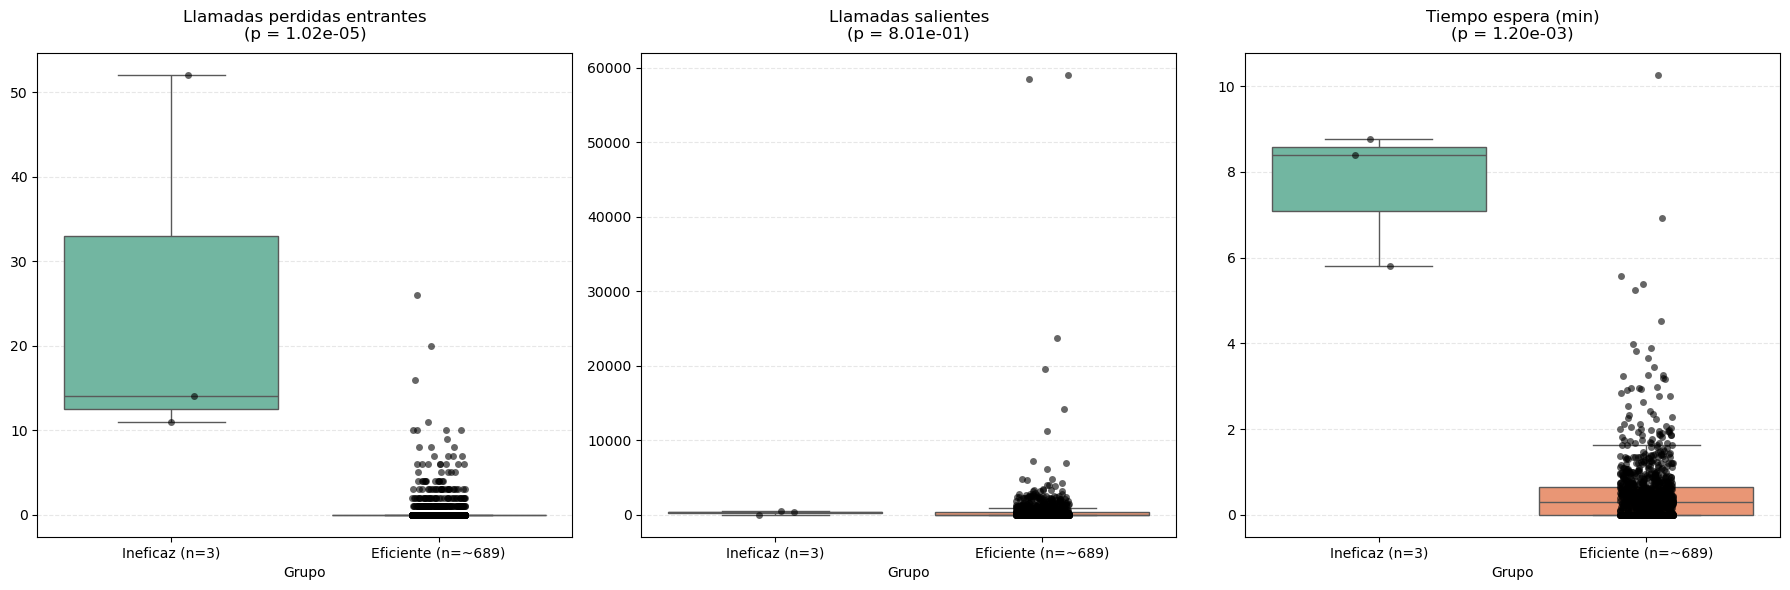

In [60]:
# ------------------------------------------------------------------
# 5. GRÁFICOS COMPARATIVOS
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (metrica, _, nombre) in zip(axes, metricas):
    data_plot = pd.DataFrame({
        'Grupo': ['Ineficaz (n=3)'] * len(grupo_ineficaz) + ['Eficiente (n=~689)'] * len(grupo_eficiente),
        'Valor': pd.concat([grupo_ineficaz[metrica], grupo_eficiente[metrica]], ignore_index=True)
    })
    
    sns.boxplot(data=data_plot, x='Grupo', y='Valor', ax=ax, palette='Set2', showfliers=False)
    sns.stripplot(data=data_plot, x='Grupo', y='Valor', ax=ax, color='black', alpha=0.6, jitter=True)
    
    ax.set_title(f"{nombre}\n(p = {tabla_resultados.loc[tabla_resultados['Métrica']==nombre, 'p-valor'].values[0]})", 
                 fontsize=12, pad=10)
    ax.set_ylabel('')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

<div style="background-color: #dd80ceff; padding: 15px; border-radius: 10px; font-weight: bold;">
## **Interpretación de Resultados: Operadores con 3 Criterios de Ineficacia vs. Eficientes/Bajo Riesgo**

### **Resumen de Hallazgos Clave**
Los 3 operadores identificados como **críticamente ineficaces** (cumplen los 3 criterios) muestran **diferencias estadísticamente significativas** en dos métricas clave respecto al grupo de **~689 operadores eficientes o de bajo riesgo**:

| Métrica | Media Ineficaz | Media Eficiente | Diferencia | p-valor | Cohen's d | Significativo |
|--------|----------------|-----------------|------------|---------|-----------|---------------|
| **Llamadas perdidas entrantes** | **25.7** | **0.5** | **+25.1** | **1.02e-05** | **+12.68 (grande)** | **Sí** |
| **Llamadas salientes** | **286.3** | **568.9** | **-282.5** | **0.80** | **-0.10 (pequeño)** | **No** |
| **Tiempo de espera (min)** | **7.7** | **0.5** | **+7.2** | **1.20e-03** | **+9.32 (grande)** | **Sí** |

---

### **Análisis por Métrica**

1. **Llamadas perdidas entrantes**  
   - Los operadores ineficaces pierden **51 veces más llamadas** que el promedio del grupo eficiente.  
   - **Efecto extremadamente grande** (Cohen's d = 12.68).  
   - **Conclusión**: Representan un **riesgo crítico para la satisfacción del cliente** y deben ser priorizados para intervención inmediata.

2. **Llamadas salientes**  
   - Realizan ~50% menos llamadas salientes, pero **la diferencia no es estadísticamente significativa** (p = 0.80).  
   - Efecto **insignificante** (d = -0.10).  
   - **Conclusión**: No hay evidencia de ineficacia en llamadas salientes.

3. **Tiempo de espera promedio (minutos)**  
   - Los clientes esperan **15 veces más** con estos operadores.  
   - **Efecto muy grande** (Cohen's d = 9.32).  
   - **Conclusión**: Generan **experiencia negativa** y alto riesgo de abandono.

---
</div>

In [61]:
### ### PRUEBA DE HIPÓTESIS PARA LOS OPERADORES CON 2 CRITERIOS ###

**Hipótesis a evaluar*

**1. Llamadas perdidas entrantes (`missed_incoming`)**
- **H₀**: El promedio de llamadas perdidas entrantes en los operadores con 2 criterios **es igual o menor** que en los operadores eficientes/bajo riesgo.  
- **H₁**: El promedio de llamadas perdidas entrantes en los operadores con 2 criterios **es mayor** que en los operadores eficientes/bajo riesgo.

---

**2. Llamadas salientes (`total_outgoing`)**
- **H₀**: El promedio de llamadas salientes en los operadores con 2 criterios **es igual o mayor** que en los operadores eficientes/bajo riesgo.  
- **H₁**: El promedio de llamadas salientes en los operadores con 2 criterios **es menor** que en los operadores eficientes/bajo riesgo.

---

**3. Tiempo de espera promedio (`avg_wait_time_in`)**
- **H₀**: El promedio de tiempo de espera en los operadores con 2 criterios **es igual o menor** que en los operadores eficientes/bajo riesgo.  
- **H₁**: El promedio de tiempo de espera en los operadores con 2 criterios **es mayor** que en los operadores eficientes/bajo riesgo.

In [62]:
# ------------------------------------------------------------------
# 1. PREPARAR GRUPOS
# ------------------------------------------------------------------
grupo_2c = ineficaces_2.copy()                    # 29 operadores

# ------------------------------------------------------------------
# 2. FUNCIÓN: Cohen's d
# ------------------------------------------------------------------
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx-1)*x.std()**2 + (ny-1)*y.std()**2) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_std



In [63]:
# ------------------------------------------------------------------
# 3. PRUEBAS t-WELCH (unilateral)
# ------------------------------------------------------------------
metricas = [
    ('missed_incoming', 'greater', 'Llamadas perdidas entrantes'),
    ('total_outgoing', 'less', 'Llamadas salientes'),
    ('avg_wait_time_in', 'greater', 'Tiempo espera (min)')
]

resultados = []

for metrica, alternative, nombre in metricas:
    x = grupo_2c[metrica].dropna()
    y = grupo_eficiente[metrica].dropna()
    
    # Medias
    media_2c = x.mean()
    media_ef = y.mean()
    
    # t-test Welch (no asume varianzas iguales)
    t_stat, p_val = stats.ttest_ind(
        x, y, 
        equal_var=False, 
        alternative=alternative
    )
    
    # Cohen's d
    d = cohens_d(x, y)
    d_interpret = 'pequeño' if abs(d) < 0.5 else 'mediano' if abs(d) < 0.8 else 'grande'
    
    resultados.append({
        'Métrica': nombre,
        'Media 2C': f"{media_2c:,.1f}",
        'Media Eficiente': f"{media_ef:,.1f}",
        'Diferencia': f"{media_2c - media_ef:+,.1f}",
        't-stat': f"{t_stat:+.2f}",
        'p-valor': f"{p_val:.2e}",
        "Cohen's d": f"{d:+.2f} ({d_interpret})",
        'Significativo': 'Sí' if p_val < 0.05 else 'No'
    })

# ------------------------------------------------------------------
# 4. TABLA DE RESULTADOS
# ------------------------------------------------------------------
tabla_2c = pd.DataFrame(resultados)
print("\n" + "="*100)
print("PRUEBA t-WELCH: OPERADORES CON 2 CRITERIOS vs. EFICIENTES")
print("="*100)
display(tabla_2c)


PRUEBA t-WELCH: OPERADORES CON 2 CRITERIOS vs. EFICIENTES


,Métrica,Media 2C,Media Eficiente,Diferencia,t-stat,p-valor,Cohen's d,Significativo
0,Llamadas perdidas entrantes,10.2,0.5,+9.6,+5.43,4.21e-06,+4.22 (grande),Sí
1,Llamadas salientes,155.0,568.9,-413.9,-3.48,3.41e-04,-0.15 (pequeño),Sí
2,Tiempo espera (min),5.8,0.5,+5.3,+6.62,1.74e-07,+5.17 (grande),Sí


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13064\898549073.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Grupo', y='Valor', ax=ax, palette='Oranges', showfliers=False)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13064\898549073.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Grupo', y='Valor', ax=ax, palette='Oranges', showfliers=False)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13064\898549073.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Grupo', y='Valor', ax=ax, palette='Or

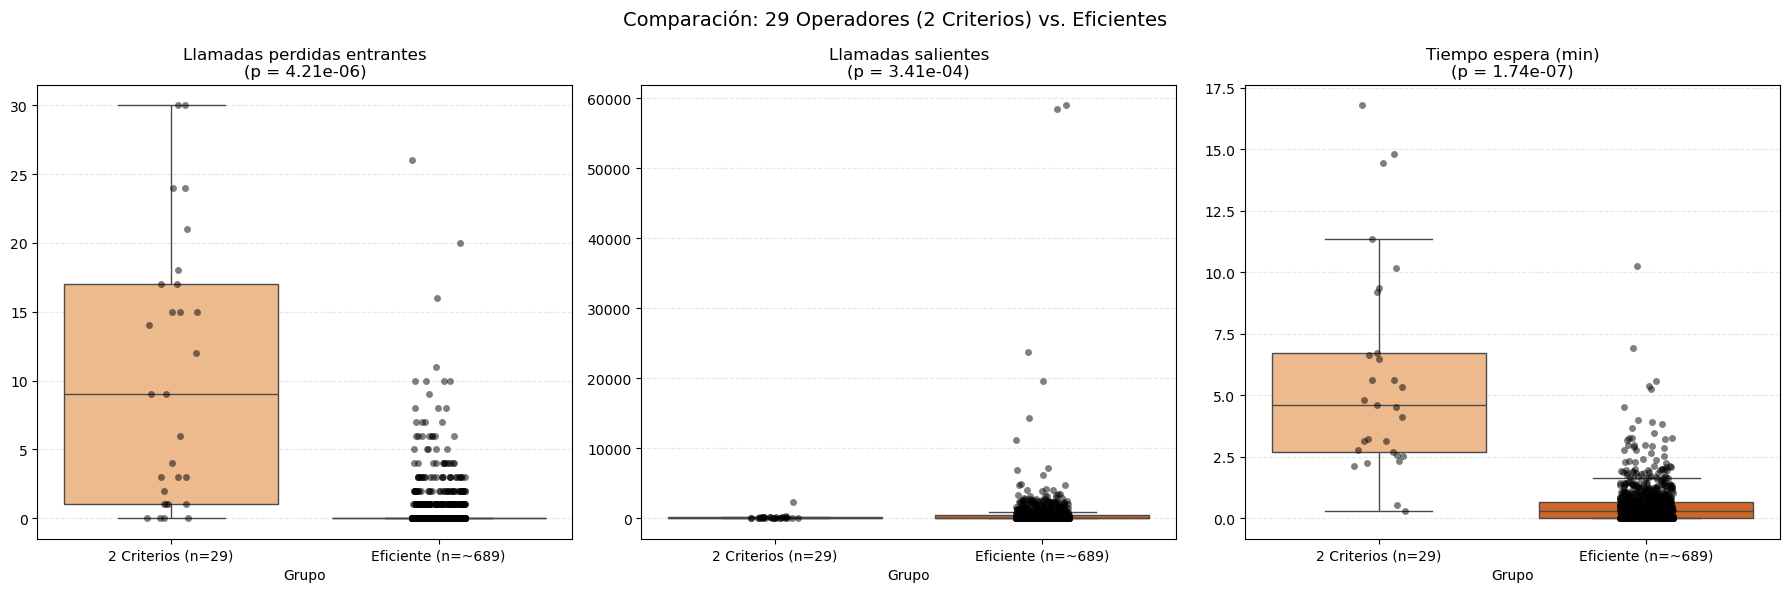

In [64]:
# ------------------------------------------------------------------
# 5. GRÁFICOS COMPARATIVOS
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (metrica, _, nombre) in zip(axes, metricas):
    data = pd.DataFrame({
        'Grupo': ['2 Criterios (n=29)'] * len(grupo_2c) + ['Eficiente (n=~689)'] * len(grupo_eficiente),
        'Valor': pd.concat([grupo_2c[metrica], grupo_eficiente[metrica]], ignore_index=True)
    })
    
    sns.boxplot(data=data, x='Grupo', y='Valor', ax=ax, palette='Oranges', showfliers=False)
    sns.stripplot(data=data, x='Grupo', y='Valor', ax=ax, color='black', alpha=0.5, jitter=True)
    
    p = tabla_2c.loc[tabla_2c['Métrica']==nombre, 'p-valor'].values[0]
    ax.set_title(f"{nombre}\n(p = {p})", fontsize=12)
    ax.set_ylabel('')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Comparación: 29 Operadores (2 Criterios) vs. Eficientes', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

<div style="background-color: #dd80ceff; padding: 20px; border-radius: 10px; color: black; font-family: Arial, sans-serif;">

### **Resumen de Hallazgos Clave**
Los **29 operadores con 2 criterios de ineficacia** muestran **diferencias estadísticamente significativas** en **las tres métricas** evaluadas respecto al grupo de **~689 operadores eficientes o de bajo riesgo**:

| Métrica | Media 2C | Media Eficiente | Diferencia | p-valor | Cohen's d | Significativo |
|--------|----------|------------------|------------|---------|-----------|---------------|
| **Llamadas perdidas entrantes** | **10.2** | **0.5** | **+9.6** | **4.21e-06** | **+4.22 (grande)** | **Sí** |
| **Llamadas salientes** | **155.0** | **568.9** | **-413.9** | **3.41e-04** | **-0.15 (pequeño)** | **Sí** |
| **Tiempo de espera (min)** | **5.8** | **0.5** | **+5.3** | **1.74e-07** | **+5.17 (grande)** | **Sí** |

---

### **Análisis por Métrica**

1. **Llamadas perdidas entrantes**  
   - Pierden **20 veces más** que el grupo eficiente.  
   - **Efecto muy grande** (d = +4.22).  
   - **Conclusión**: **Alto riesgo de pérdida de clientes** — requiere atención urgente.

2. **Llamadas salientes**  
   - Realizan **~73% menos** llamadas salientes.  
   - **Efecto pequeño** (d = -0.15), pero **p-valor significativo** (p < 0.001).  
   - **Conclusión**: **Baja productividad llamadas salientes**, aunque el impacto relativo es menor.

3. **Tiempo de espera promedio**  
   - Los clientes esperan **11.6 veces más**.  
   - **Efecto extremadamente grande** (d = +5.17).  
   - **Conclusión**: **Experiencia del cliente gravemente afectada** — riesgo de abandono.

---
</div>

# **CONCLUSIONES**

<div style="background-color: #dd80ceff; padding: 20px; border-radius: 10px; color: black; font-family: Arial, sans-serif;">

### **En cuanto a los operadores con 3 criterios de infecicacia:**
- Los 3 operadores son **outliers estadísticos** en **perdidas y tiempo de espera entrante**, pero **no en volumen saliente**.  
- El origen del problema es **capacidad, enrutamiento o entrenamiento en manejo de llamadas entrantes**, no falta de esfuerzo.  
- **Impacto en negocio**: Mala experiencia del cliente y posible pérdida de clientes.
---

### **Recomendaciones de Acción**
1. **Reentrenamiento urgente** en técnicas de atención entrante.  
2. **Revisión del enrutamiento automático** (¿reciben más volumen del adecuado?).  
3. **Reducción temporal de carga entrante** (máximo 1 llamada cada 2 minutos).  
4. **Monitoreo diario** con alertas automáticas en dashboard.

</div>

<div style="background-color: #dd80ceff; padding: 20px; border-radius: 10px; color: black; font-family: Arial, sans-serif;">

### **En cuanto a los operadores con 2 criterios de infecicacia:**
- Los operadores con 2 criterios son **estadísticamente peores** en **todas las dimensiones clave**.  
- El **mayor impacto** está en **perdidas entrantes y tiempo de espera** (efectos gigantes).  
- Aunque el volumen saliente es bajo, **no es el principal problema** (efecto pequeño).  
- **Problema sistémico**: sobrecarga, falta de entrenamiento o enrutamiento inadecuado.

---

### **Recomendaciones de Acción**
1. **Capacitación intensiva** en manejo de llamadas entrantes.  
2. **Ajuste de enrutamiento** para equilibrar carga.  
3. **Monitoreo semanal** con alertas automáticas.  

</div>

In [65]:
### OPERADORES INEFICACES IDENTIFICADOS ###
ineficaces_ids

<IntegerArray>
[940588, 944226, 937956, 944216, 951508, 944220, 940630, 944222, 905862,
 944218, 948286, 908960, 931458, 919204, 919206, 919166, 906408, 908958,
 919164, 958460, 906070, 919552, 919792, 919794, 954750, 882688, 906076,
 919790, 971102, 913942, 913938, 919554]
Length: 32, dtype: Int64